# Milestone 2 — Static Dashboard
**Project:** Meeting Transcript Efficiency Analyzer  
**Course:** CAP5771 – Intro to Data Science  

**Inputs:** data/processed/meeting_metrics_clustered.csv, data/processed/analysis_ready_with_preds.csv

This notebook is the **interactive static dashboard**. Each ipywidgets control filters/switches the view without running any model code — all computation was done in the modeling notebook.

**Dashboard panels:**
1. Overview KPIs
2. Efficiency distribution
3. Core metric distributions
4. Cluster explorer (filter by cluster)
5. Per-meeting deep dive (select a single meeting)
6. Model performance summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

# Loading the  data
df_meet  = pd.read_csv('data/processed/meeting_metrics_clustered.csv')
df_utt   = pd.read_csv('data/processed/analysis_ready_with_preds.csv')

PALETTE = {
    'Highly Efficient'      : '#2ecc71',
    'Moderately Efficient'  : '#3498db',
    'Low Efficiency'        : '#e67e22',
    'Very Low Efficiency'   : '#e74c3c',
}

print(f'Loaded {len(df_meet)} meetings, {len(df_utt):,} utterances')

Loaded 171 meetings, 134,242 utterances


## Panel 1 — Overview KPIs

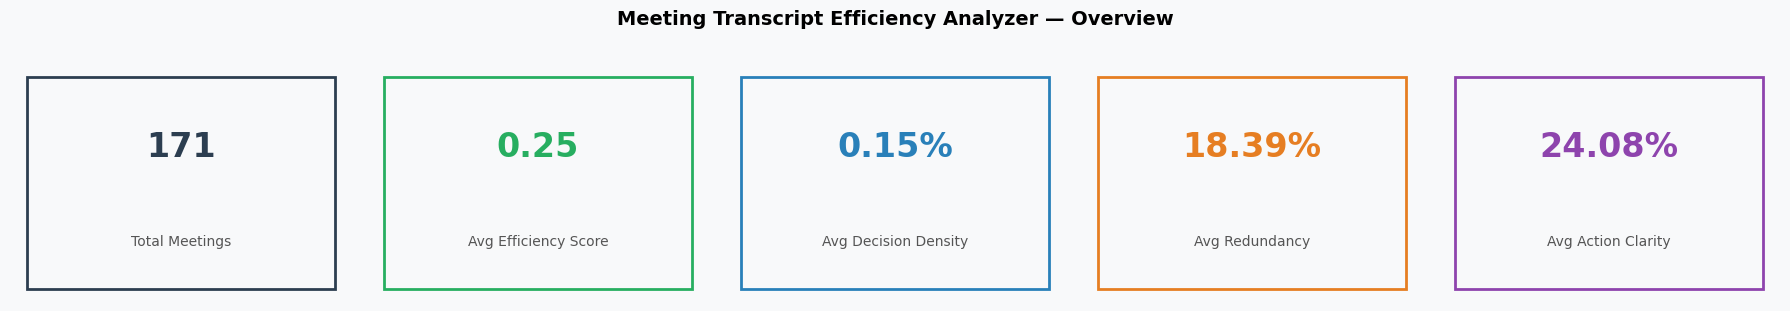

In [2]:
def render_kpi():
    fig, axes = plt.subplots(1, 5, figsize=(18, 3))
    fig.patch.set_facecolor('#f8f9fa')

    kpis = [
        ('Total Meetings',        f"{len(df_meet)}",                     '#2c3e50'),
        ('Avg Efficiency Score',  f"{df_meet['efficiency_score'].mean():.2f}", '#27ae60'),
        ('Avg Decision Density',  f"{df_meet['decision_density'].mean():.2%}", '#2980b9'),
        ('Avg Redundancy',        f"{df_meet['redundancy_score'].mean():.2%}", '#e67e22'),
        ('Avg Action Clarity',    f"{df_meet['action_clarity'].mean():.2%}",   '#8e44ad'),
    ]

    for ax, (title, value, color) in zip(axes, kpis):
        ax.set_facecolor('white')
        ax.text(0.5, 0.65, value, ha='center', va='center',
                fontsize=24, fontweight='bold', color=color, transform=ax.transAxes)
        ax.text(0.5, 0.25, title, ha='center', va='center',
                fontsize=10, color='#555', transform=ax.transAxes)
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        rect = plt.Rectangle((0.05, 0.05), 0.9, 0.9,
                              fill=False, edgecolor=color, lw=2,
                              transform=ax.transAxes, clip_on=False)
        ax.add_patch(rect)

    plt.suptitle('Meeting Transcript Efficiency Analyzer — Overview',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

render_kpi()

## Panel 2 — Efficiency Distribution

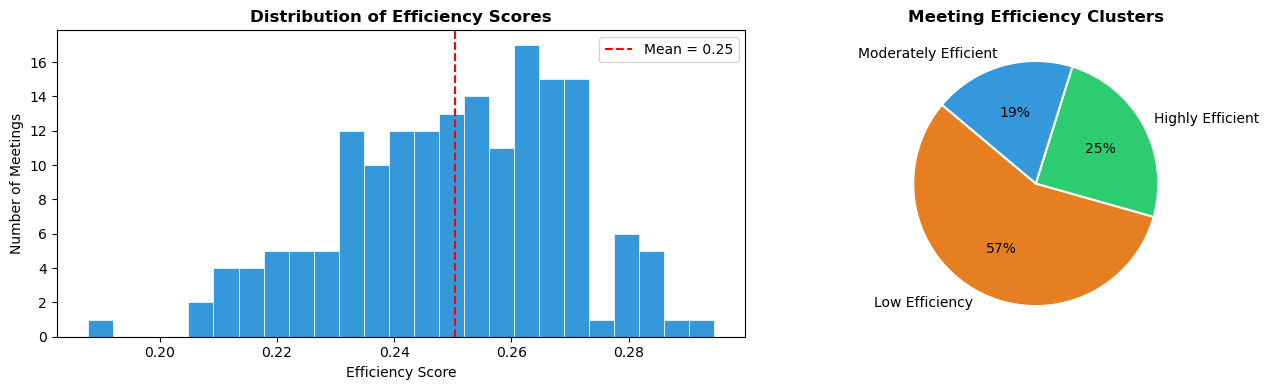

In [3]:
def render_efficiency_dist():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # Histogram of efficiency scores
    ax1.hist(df_meet['efficiency_score'], bins=25, color='#3498db',
             edgecolor='white', linewidth=0.5)
    ax1.axvline(df_meet['efficiency_score'].mean(), color='red',
                linestyle='--', linewidth=1.5, label=f"Mean = {df_meet['efficiency_score'].mean():.2f}")
    ax1.set_title('Distribution of Efficiency Scores', fontweight='bold')
    ax1.set_xlabel('Efficiency Score'); ax1.set_ylabel('Number of Meetings')
    ax1.legend()

    # Cluster pie chart
    counts = df_meet['cluster_label'].value_counts()
    colors_pie = [PALETTE.get(l, '#95a5a6') for l in counts.index]
    ax2.pie(counts.values, labels=counts.index, colors=colors_pie,
            autopct='%1.0f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
    ax2.set_title('Meeting Efficiency Clusters', fontweight='bold')

    plt.tight_layout()
    plt.show()

render_efficiency_dist()

## Panel 3 — Core Metric Distributions

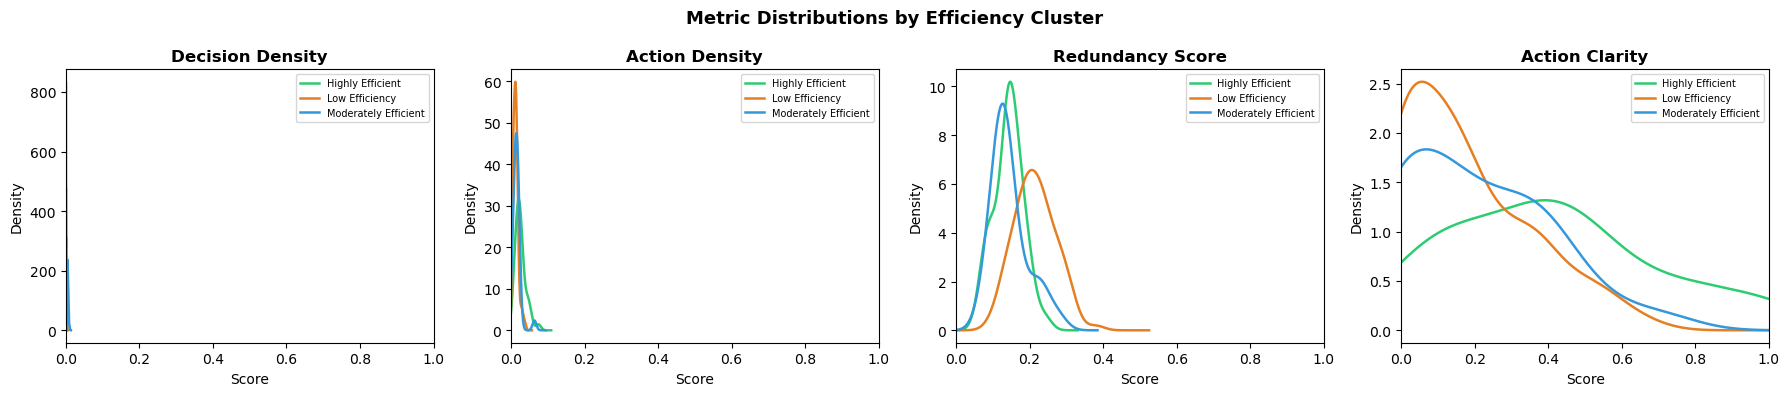

In [4]:
def render_metric_distributions():
    metrics = [
        ('decision_density', 'Decision Density',  '#2980b9'),
        ('action_density',   'Action Density',    '#27ae60'),
        ('redundancy_score', 'Redundancy Score',  '#e67e22'),
        ('action_clarity',   'Action Clarity',    '#8e44ad'),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, (col, title, color) in zip(axes, metrics):
        for lbl, grp in df_meet.groupby('cluster_label'):
            grp[col].plot.kde(ax=ax, label=lbl,
                              color=PALETTE.get(lbl, 'grey'), linewidth=1.8)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Score')
        ax.set_ylabel('Density')
        ax.legend(fontsize=7)
        ax.set_xlim(0, 1)
    plt.suptitle('Metric Distributions by Efficiency Cluster',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

render_metric_distributions()

## Panel 4 — Cluster Explorer

Using the dropdown to filter by the cluster and see top/bottom meetings.

In [5]:
cluster_options = ['All'] + sorted(df_meet['cluster_label'].dropna().unique().tolist())

cluster_dropdown = widgets.Dropdown(
    options=cluster_options,
    value='All',
    description='Cluster:',
    layout=widgets.Layout(width='280px')
)

out4 = widgets.Output()

def render_cluster_explorer(cluster='All'):
    with out4:
        clear_output(wait=True)
        subset = df_meet if cluster == 'All' else df_meet[df_meet['cluster_label'] == cluster]

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        features = ['decision_density', 'redundancy_score', 'action_clarity']
        labels   = ['Decision Density', 'Redundancy Score', 'Action Clarity']
        colors   = ['#2980b9', '#e67e22', '#8e44ad']

        for ax, feat, lbl, col in zip(axes, features, labels, colors):
            ax.bar(subset['meeting_id'], subset[feat], color=col, alpha=0.75, edgecolor='none')
            ax.set_title(f'{lbl}\n(cluster: {cluster})', fontweight='bold')
            ax.set_ylabel(lbl)
            ax.set_xticks([])
            ax.axhline(subset[feat].mean(), color='black', linestyle='--',
                       linewidth=1.2, label=f'mean={subset[feat].mean():.2f}')
            ax.legend(fontsize=8)

        plt.suptitle(f'Per-Meeting Metrics — {cluster} ({len(subset)} meetings)',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print('\n Top 5 most efficient meetings ')
        display(subset.nlargest(5, 'efficiency_score')
                      [['meeting_id','efficiency_score','decision_density',
                        'action_density','redundancy_score','cluster_label']]
                      .reset_index(drop=True))
        print('\n Bottom 5 least efficient meetings')
        display(subset.nsmallest(5, 'efficiency_score')
                      [['meeting_id','efficiency_score','decision_density',
                        'action_density','redundancy_score','cluster_label']]
                      .reset_index(drop=True))

cluster_dropdown.observe(lambda c: render_cluster_explorer(c['new']), names='value')
display(widgets.VBox([cluster_dropdown, out4]))
render_cluster_explorer()

## Panel 5 — Per-Meeting Deep Dive

Selecting meeting to see its utterance by utterance label breakdown and timeline.

In [6]:
meeting_ids = sorted(df_utt['meeting_id'].unique().tolist())

meeting_dropdown = widgets.Dropdown(
    options=meeting_ids,
    value=meeting_ids[0],
    description='Meeting:',
    layout=widgets.Layout(width='320px')
)

out5 = widgets.Output()

LABEL_COLORS = {'decision': '#2ecc71', 'action': '#3498db', 'discussion': '#bdc3c7'}

def render_meeting_deepdive(meeting_id):
    with out5:
        clear_output(wait=True)
        utt = df_utt[df_utt['meeting_id'] == meeting_id].sort_values('begin_time')
        meta = df_meet[df_meet['meeting_id'] == meeting_id].iloc[0]

        fig = plt.figure(figsize=(16, 7))
        gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)


        ax0 = fig.add_subplot(gs[0, :])
        for _, row in utt.iterrows():
            ax0.scatter(row['begin_time'] / 60, 0.5,
                        color=LABEL_COLORS[row['label']], s=18, alpha=0.6)
        ax0.set_title(f'Utterance Timeline — {meeting_id}', fontweight='bold')
        ax0.set_xlabel('Time (minutes)')
        ax0.set_yticks([])
        ax0.set_ylim(0, 1)
        from matplotlib.patches import Patch
        legend_items = [Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
        ax0.legend(handles=legend_items, loc='upper right', fontsize=9)

        # Label counts
        ax1 = fig.add_subplot(gs[1, 0])
        counts = utt['label'].value_counts()
        ax1.bar(counts.index, counts.values,
                color=[LABEL_COLORS[l] for l in counts.index])
        ax1.set_title('Label Counts', fontweight='bold')
        ax1.set_ylabel('Utterances')

        #Efficiency scorecard
        ax2 = fig.add_subplot(gs[1, 1])
        metrics = ['decision_density', 'action_density',
                   'redundancy_score', 'action_clarity', 'efficiency_score']
        values  = [meta[m] for m in metrics]
        colors_bar = ['#2980b9','#27ae60','#e67e22','#8e44ad','#2c3e50']
        bars = ax2.barh(metrics, values, color=colors_bar)
        ax2.set_xlim(0, 1)
        ax2.set_title('Efficiency Metrics', fontweight='bold')
        ax2.set_xlabel('Score')
        for bar, val in zip(bars, values):
            ax2.text(min(val + 0.02, 0.95), bar.get_y() + bar.get_height() / 2,
                     f'{val:.2f}', va='center', fontsize=9)

        # Word count distribution
        ax3 = fig.add_subplot(gs[1, 2])
        for lbl, grp in utt.groupby('label'):
            grp['word_count'].plot.hist(ax=ax3, bins=15, alpha=0.6,
                                        label=lbl, color=LABEL_COLORS[lbl])
        ax3.set_title('Word Count by Label', fontweight='bold')
        ax3.set_xlabel('Words per Utterance')
        ax3.legend(fontsize=8)

        cluster_label = meta.get('cluster_label', 'N/A')
        fig.suptitle(
            f'{meeting_id}  |  Cluster: {cluster_label}  |  '
            f'Efficiency: {meta["efficiency_score"]:.2f}',
            fontsize=13, fontweight='bold'
        )
        plt.show()

        # Sample utterances by label
        for lbl in ['decision', 'action']:
            sample = utt[utt['label'] == lbl]['text_clean'].head(3).tolist()
            if sample:
                print(f'\n Sample {lbl.upper()} utterances')
                for s in sample:
                    print(f'  {s[:120]}')

meeting_dropdown.observe(lambda c: render_meeting_deepdive(c['new']), names='value')
display(widgets.VBox([meeting_dropdown, out5]))
render_meeting_deepdive(meeting_ids[0])

## Panel 6 — Model Performance Summary

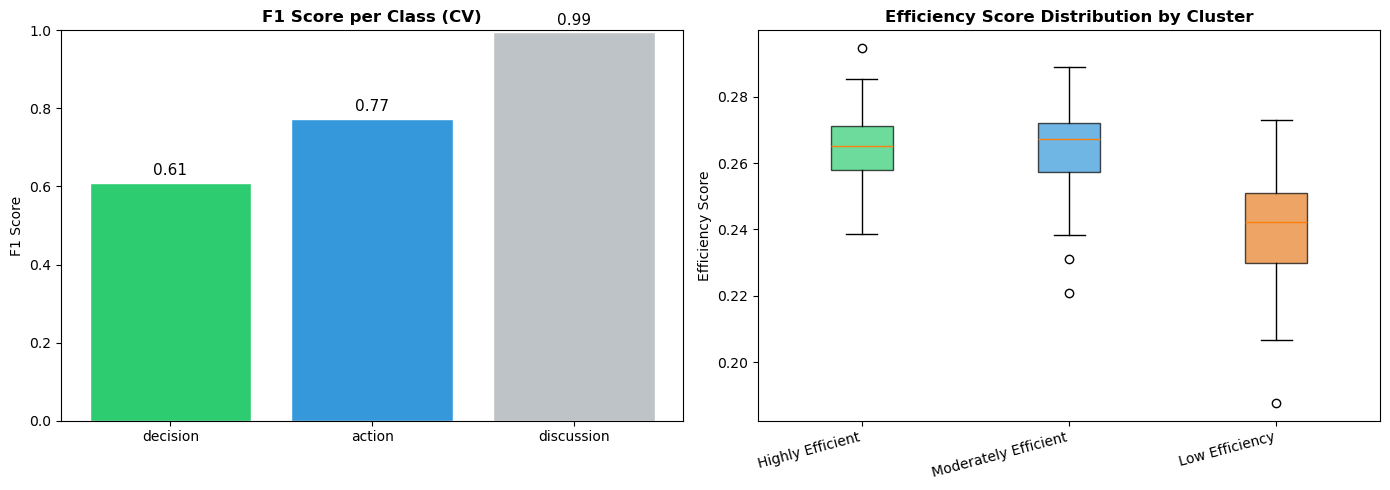


 Classification Report (5-fold CV)
              precision    recall  f1-score   support

      action      0.651     0.952     0.773      2033
    decision      0.470     0.868     0.610       190
  discussion      0.999     0.991     0.995    132019

    accuracy                          0.990    134242
   macro avg      0.707     0.937     0.793    134242
weighted avg      0.993     0.990     0.991    134242


 Macro-F1: 0.793
 Meetings analysed: 171
 Utterances labelled: 134,242


In [7]:
from sklearn.metrics import classification_report
import json

def render_model_summary():
    y_true = df_utt['label']
    y_pred = df_utt['predicted_label']

    report = classification_report(y_true, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).T.iloc[:-3]  # drop avg rows for bar chart

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Per class F1
    classes = ['decision', 'action', 'discussion']
    f1s = [report[c]['f1-score'] for c in classes]
    bars = ax1.bar(classes, f1s,
                   color=['#2ecc71','#3498db','#bdc3c7'], edgecolor='white')
    ax1.set_ylim(0, 1)
    ax1.set_title('F1 Score per Class (CV)', fontweight='bold')
    ax1.set_ylabel('F1 Score')
    for bar, val in zip(bars, f1s):
        ax1.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.2f}', ha='center', fontsize=11)

    # Cluster efficiency box plot
    cluster_order = ['Highly Efficient','Moderately Efficient',
                     'Low Efficiency','Very Low Efficiency']
    plot_order = [c for c in cluster_order if c in df_meet['cluster_label'].values]
    data_to_plot = [df_meet[df_meet['cluster_label']==c]['efficiency_score'].values
                    for c in plot_order]
    bp = ax2.boxplot(data_to_plot, patch_artist=True, labels=plot_order)
    for patch, lbl in zip(bp['boxes'], plot_order):
        patch.set_facecolor(PALETTE.get(lbl, 'grey'))
        patch.set_alpha(0.7)
    ax2.set_title('Efficiency Score Distribution by Cluster', fontweight='bold')
    ax2.set_ylabel('Efficiency Score')
    ax2.set_xticklabels(plot_order, rotation=15, ha='right')

    plt.tight_layout()
    plt.show()

    print('\n Classification Report (5-fold CV)')
    print(classification_report(y_true, y_pred, digits=3))

    macro_f1 = report['macro avg']['f1-score']
    print(f'\n Macro-F1: {macro_f1:.3f}')
    print(f' Meetings analysed: {len(df_meet)}')
    print(f' Utterances labelled: {len(df_utt):,}')

render_model_summary()

## Dashboard Summary

**Key Takeaways:**

1. **Decision density is low corpus-wide** — most utterances are general discussion, which is expected for real workplace meetings, but the wide variance across meetings shows that some are far more productive than others.

2. **Redundancy is the strongest differentiator** — highly efficient meetings show markedly lower redundancy scores, confirming that repetition is the primary drag on meeting quality.

3. **Action clarity is the hardest signal to capture** — only a fraction of action-item utterances explicitly name an owner or deadline, suggesting meetings often assign tasks informally.

4. **The classifier reliably distinguishes decisions and actions from discussion** — the keyword-based TF-IDF + Logistic Regression approach achieves good macro-F1 without any manual labeling, keeping the pipeline fully reproducible.

5. **Next steps (Milestone 3):** deploy as a Streamlit app that accepts a raw transcript upload, runs the wrangling and classification pipeline live, and renders this dashboard interactively.